# Single-Pixel Decay Simulation

Simulate many independent single-pixel fluorescence decays, mimicking a
Fluorescence Lifetime Imaging Microscopy (FLIM) acquisition, and inspect the
resulting parameter distributions. This notebook walks through:

- loading an instrument response function (IRF) and computing the excitation
  frequency,
- choosing a mono- or bi-exponential decay model and configuring detector /
  noise settings (jitter, dark counts, shot noise, quantization),
- batching many independent single-pixel simulations via `make_simulator`, and
- visualizing the simulated decays alongside the resulting lifetime and
  amplitude parameter distributions.

In [52]:
## importing the modules required for this work
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# package from PyFli
from pyfli.io import DataOperations 
from pyfli.simulator import PhotonCountSimulator
from pyfli.analytical_methods import AnalyticalHelpers
from pyfli.data_cc import Normalization

In [2]:
IRF_PATH = "<select file/folder path>"

In [6]:
loader = DataOperations(irf_path=IRF_PATH)
irf_data = loader.load_irf()
print(f'IRF data shape is: {irf_data.shape}')

gate_delay = 12.5/irf_data.shape[2]
num_gates = irf_data.shape[2]
freq = AnalyticalHelpers(laser_period = 12.5, gate_delay=gate_delay, num_gate = num_gates).freq_computation()
freq_hz = freq[1] * 1e6
print(f'the frequency use is: {freq[1]} MHz')

INFO:pyfli:Initiating IRF load from: <select file/folder path>


IRF data shape is: (512, 512, 256)
the frequency use is: 80.0 MHz


In [41]:
# select the type of decay model to simulate
MODEL_TYPE = "bi-exponential"

if MODEL_TYPE == "bi-exponential":
    mono_fraction = 0.0
elif MODEL_TYPE == "mono-exponential":
    mono_fraction = 1.0

In [43]:
# Manipulate the simulator parameters

config = {
    # Modular Noise
    "jitter":        [True, False][0],   # temporal jitter shift
    "dcr_on":        [True, False][0],   # Dark Count Rate (thermal background)
    "poisson":       [True, False][0],   # Shot noise — Macro_sim only
    "qe_on":         [True, False][0],   # Quantum efficiency scaling
    "read_noise_on": [True, False][0],   # Gaussian read noise — Macro_sim / ICCD only

    # Sensor
    "sensor_type": "PHOTON_COUNTER",     # "ICCD" (Macro_sim) | "PHOTON_COUNTER" (TCSPC_sim)
    # "bit":          10,                # ADC bit depth for ICCD; TCSPC defaults to 16 if unset
    "dcr":          0.08,                # Mean dark counts per bin
    "laser_feq":    80,                  # Laser repetition rate (MHz) → period = 12.5 ns
    "round_on":    [True, False][0],     # Round photon counts to integers — Macro_sim only
    "clip_on":     [True, False][0],     # Clip at bit-depth ceiling — Macro_sim: max_adc_val; TCSPC: max_bin_count

    # Fluorescence Physics (FLI / FRET)
    "tau2":          (1, 1),             # τ₂ ~ TruncNormal(mu=1 ns, sigma=0.5 ns)
    "tau2_dist":     "beta",             # if dist "beta" or "normal" (default)
    'tau2_beta_range': (3, 0.1),   # (scale, range)
    "efficiency":    (1, 1),             # FRET efficiency E ~ Beta(2, 5)  → [0.1, 1.0]
    "A1_fraction":   (1, 1),             # Amplitude fraction A₁ ~ Beta(2, 5) → [0.05, 0.95]
    "photo_count":   (1, 1),             # Peak intensity ~ Beta(2, 5) × max_adc — Macro_sim only
    "mono_fraction":  mono_fraction,     # Fraction of pixels forced mono-exponential (0.0 = all bi-exp)
    "n_cycles":      1_000_000,          # Accumulation cycles — TCSPC_sim only
}

In [44]:
def concat_sim_data(*datasets):
    """
    Concatenate multiple sim.sample() output dicts along the batch axis (axis=0).
    Assumes all datasets share identical keys and per-sample shapes.
    """
    keys = datasets[0].keys()
    # sanity check: all datasets must have the same keys
    for i, d in enumerate(datasets[1:], start=1):
        if set(d.keys()) != set(keys):
            missing = set(keys) - set(d.keys())
            extra = set(d.keys()) - set(keys)
            raise ValueError(f"Key mismatch in dataset {i}: missing={missing}, extra={extra}")

    combined = {}
    for k in keys:
        arrs = [d[k] for d in datasets]
        combined[k] = np.concatenate(arrs, axis=0)
    return combined


class SimOutput:
    def __init__(self, simulator):
        self.simulator = simulator

    def run(self):
        val = self.simulator()
        maps = val['results']['maps']
        if maps['mono_map']:
            tau1 = tau2 = tau = maps['tau_map']
            alpha1 = 1.0
            efficiency = 1.0
        else:
            tau1, tau2 = maps['tau1_map'], maps['tau2_map']
            tau = maps['tau_mean_map']
            alpha1 = maps['alpha1_map']
            efficiency =  maps["fret_efficiency_map"]
        return {'decay': val['raw_data']['decay'],
                'irf_': val['raw_data']['irf'],
                'tau1': tau1,
                'tau2': tau2,
                'tau': tau,
                'alpha1': alpha1,
                'photon_count': maps['photon_count_map'],
                'Efficiency': efficiency}
            
class SimOutputWithIRFOffset(SimOutput):
    def __init__(self, simulator, irf_1d):
        super().__init__(simulator)
        self.irf_1d = irf_1d

    def _compute_irf_offset(self):
        i_off = self.irf_1d
        i_off_sum = i_off.sum()
        if not np.isfinite(i_off_sum) or i_off_sum <= 0:
            raise ValueError(f"Invalid IRF: sum={i_off_sum}. IRF must be non-negative and non-zero.")
        i_off = i_off / i_off_sum
        return i_off

    def run(self):
        out = super().run()
        out['irf'] = self._compute_irf_offset()
        return out


class SimGenerator:
    """
    Wraps IRF shifting + PhotonCountSim + SimOutputWithIRFOffset for a
    single config. Only accepts one config dict — raises if given a
    list/tuple of configs.
    """

    def __init__(self, irf_data, config, a_range=(-20, 100), b_range=(0, 10), pixel=(0, 0)):
        if isinstance(config, (list, tuple)):
            raise TypeError(
                "SimGenerator accepts exactly one config dict, not a "
                "list/tuple of configs. Instantiate one generator per config "
                "and combine their sampled outputs afterward if you need "
                "multiple configs."
            )
        if not isinstance(config, dict):
            raise TypeError(f"config must be a dict, got {type(config)}")

        self.config = config
        self.a_range = a_range
        self.b_range = b_range
        self.I_base = irf_data[pixel[0], pixel[1], :].astype(float)  # shape (n_bins,)
        self.n_bins = self.I_base.shape[0]

    def _make_shifted_irf_1d(self, a, b):
        """
        Circular shift I(t) -> I(t-a), add offset b. Returns 1D (n_bins,).
        NOTE: np.roll requires an integer shift; `a` is rounded to the
        nearest int here since it's sampled from a continuous uniform range.
        """
        a_int = int(round(a))
        return np.roll(self.I_base, a_int) + b

    def simulate_once(self):
        a = np.random.uniform(*self.a_range)
        b = np.random.uniform(*self.b_range)
        irf_1d = self._make_shifted_irf_1d(a, b)

        fli_simulator = PhotonCountSimulator(irf_data=irf_1d, **self.config)
        out = SimOutputWithIRFOffset(fli_simulator, irf_1d).run()
        out['h_shift'] = a
        out['v_shift'] = b
        return out

In [46]:
def make_simulator(simulate_fn, num_samples):
    """Run simulate_fn num_samples times and stack each output key along a new leading axis."""
    samples = [simulate_fn() for _ in range(num_samples)]
    keys = samples[0].keys()
    return {key: np.stack([np.asarray(s[key]) for s in samples], axis=0) for key in keys}


In [ ]:
sim = SimGenerator(irf_data, config, a_range=(-20, 100), b_range=(0, 10))

In [50]:
NUM_SAMPLES = 100
sim_data = make_simulator(sim.simulate_once, NUM_SAMPLES)

In [51]:
sim_data['decay'].shape

(100, 256)

In [55]:
sim_data.keys()

dict_keys(['decay', 'irf_', 'tau1', 'tau2', 'tau', 'alpha1', 'photon_count', 'Efficiency', 'irf', 'h_shift', 'v_shift'])

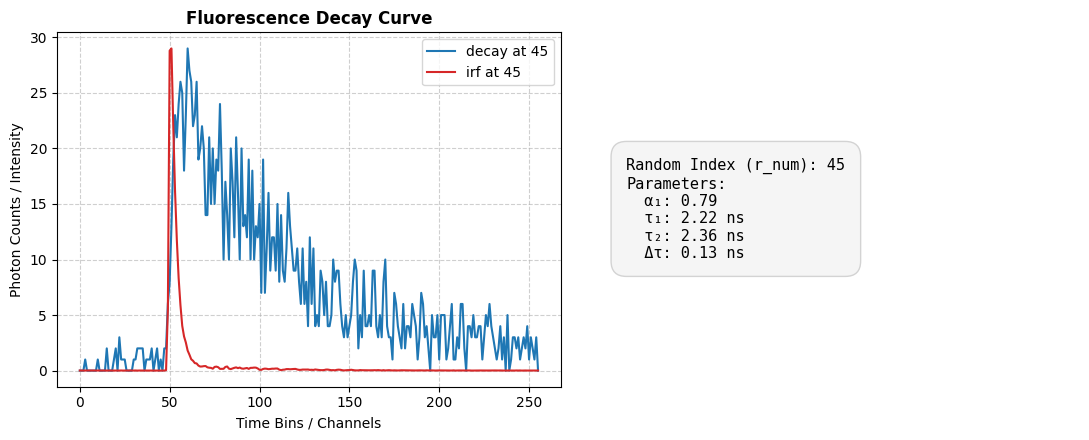

In [68]:
r_num = np.random.randint(NUM_SAMPLES)
tau_dif = sim_data["tau2"] - sim_data["tau1"]

# print(f"r_num: {r_num}")
# print(f'(alpha, tau1, tau2): ({test_data["alpha1"][r_num][0]:.2f}, {test_data["tau1"][r_num][0]:.2f}, {test_data["tau2"][r_num][0]:.2f})')
# print(f'tau2-tau1: {tau_diff:.2f} ns')

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5))

axs[0].plot(sim_data["decay"][r_num], color='tab:blue', linewidth=1.5, label=f"decay at {r_num}")
axs[0].plot(Normalization(sim_data["irf"][r_num]).norm_scale(sim_data["decay"][r_num]), color='tab:red', linewidth=1.5, label=f"irf at {r_num}")
axs[0].set_title("Fluorescence Decay Curve", fontsize=12, fontweight='bold')
axs[0].set_xlabel("Time Bins / Channels", fontsize=10)
axs[0].set_ylabel("Photon Counts / Intensity", fontsize=10)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[0].legend(loc='upper right')

axs[1].axis('off')  
text_content = (
    f"Random Index (r_num): {r_num}\n"
    f"Parameters:\n"
    f"  α₁: {sim_data['alpha1'][r_num]:.2f}\n"
    f"  τ₁: {sim_data['tau1'][r_num]:.2f} ns\n"
    f"  τ₂: {sim_data['tau2'][r_num]:.2f} ns\n"
    f"  Δτ: {tau_dif[r_num]:.2f} ns"
)

axs[1].text(0.1, 0.5, text_content, fontsize=11, family='monospace', va='center', ha='left',
            bbox=dict(boxstyle='round,pad=1', facecolor='whitesmoke', edgecolor='lightgray'))

plt.tight_layout()


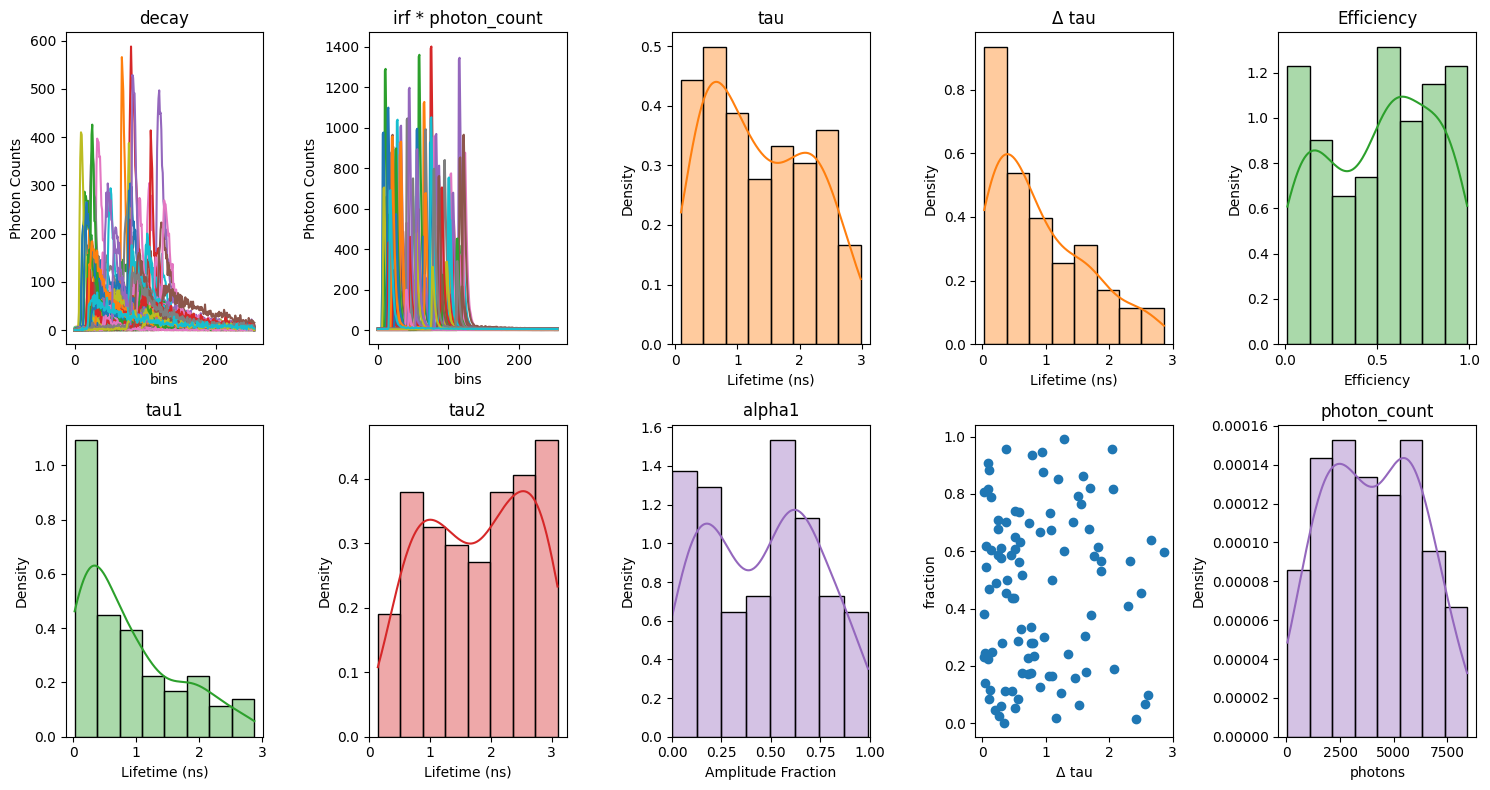

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns  # Used for seamless histogram + KDE overlay

fig, axes = plt.subplots(2, 5, figsize=(15, 8))


axes[0, 0].plot((sim_data["decay"]).T)
axes[0, 0].set_title("decay")
axes[0, 0].set_xlabel("bins")
axes[0, 0].set_ylabel("Photon Counts")

axes[0, 1].plot((sim_data["irf"]).T * (sim_data["photon_count"]).T)
axes[0, 1].set_title("irf * photon_count")
axes[0, 1].set_xlabel("bins")
axes[0, 1].set_ylabel("Photon Counts")


sns.histplot(data=sim_data["tau"].flatten(), ax=axes[0, 2], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 2].set_title("tau")
axes[0, 2].set_xlabel("Lifetime (ns)")

sns.histplot(data=tau_dif.flatten(), ax=axes[0, 3], kde=True, stat="density", color="tab:orange", alpha=0.4)
axes[0, 3].set_title("Δ tau")
axes[0, 3].set_xlabel("Lifetime (ns)")


sns.histplot(data=sim_data['Efficiency'].flatten(), ax=axes[0, 4], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[0, 4].set_title("Efficiency")
axes[0,  4].set_xlabel("Efficiency")

sns.histplot(data=sim_data["tau1"].flatten(), ax=axes[1, 0], kde=True, stat="density", color="tab:green", alpha=0.4)
axes[1, 0].set_title("tau1")
axes[1, 0].set_xlabel("Lifetime (ns)")


sns.histplot(data=sim_data["tau2"].flatten(), ax=axes[1, 1], kde=True, stat="density", color="tab:red", alpha=0.4)
axes[1, 1].set_title("tau2")
axes[1, 1].set_xlabel("Lifetime (ns)")

sns.histplot(data=sim_data["alpha1"].flatten(), ax=axes[1, 2], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 2].set_title("alpha1")
axes[1, 2].set_xlabel("Amplitude Fraction")
axes[1, 2].set_xlim(0.0, 1.0)


sns.histplot(data=sim_data['photon_count'].flatten(), ax=axes[1, 4], kde=True, stat="density", color="tab:purple", alpha=0.4)
axes[1, 4].set_title("photon_count")
axes[1, 4].set_xlabel("photons")
# axes[1, 4].set_xlim(0.0, 1.0)



axes[1, 3].scatter(tau_dif, sim_data["alpha1"])
axes[1, 3].set_xlabel("Δ tau")
axes[1, 3].set_ylabel("fraction")

plt.tight_layout()
plt.show()